# **CV ASSIGNMENT**
**Name:** Varsha Shivanand K

**USN:** 1RUA24CSE0516

B.Tech 5th Semester - Section F

# **1.5 Application Problems -**

## **1) High-Boost Filtering**

Implement a high-boost filtering system that enhances high-frequency components while retaining part of the original image:

$$
f_{hb} = (A - 1)f_{orig} + f_{sharpened}
$$

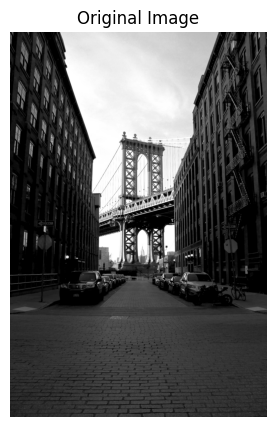

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread("image.jpg", 0)

if img is None:
    raise FileNotFoundError("Image not found. Check the file path.")

img = img.astype(np.float32)

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

Extract high-frequency detail via Gaussian blur subtraction

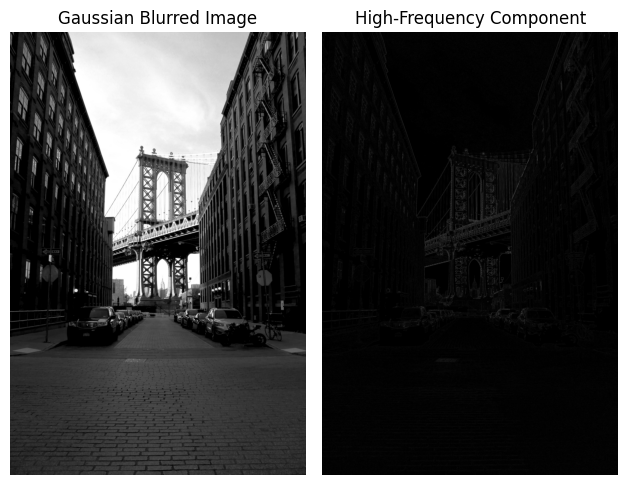

In [2]:
# Apply Gaussian blur
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# Extract high-frequency component
high_freq = img.astype(np.float32) - blurred.astype(np.float32)

# High-frequency component for visualization
high_freq_display = cv2.normalize(
    np.abs(high_freq),
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.subplot(1, 2, 1)
plt.imshow(blurred, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_freq_display, cmap='gray')
plt.title("High-Frequency Component")
plt.axis("off")

plt.tight_layout()
plt.show()

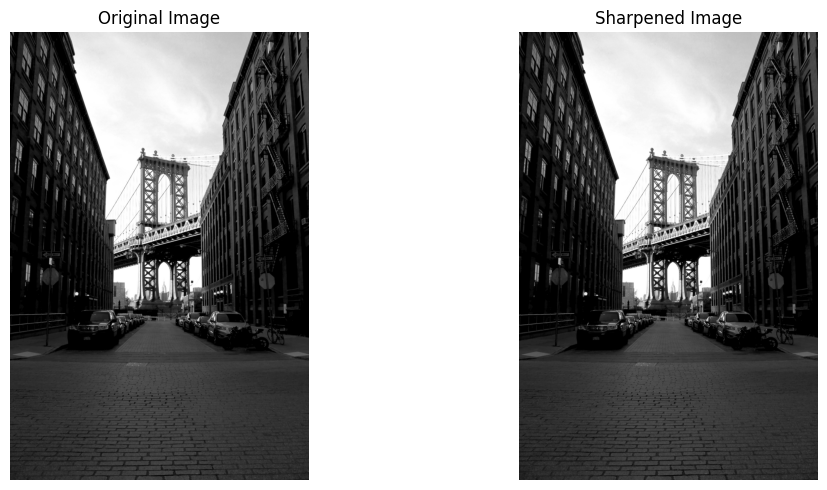

In [3]:
# Create sharpened image
sharpened = img + high_freq

# Clip to valid image range
sharpened = np.clip(sharpened, 0, 255)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()

Apply high-boost formula
$$
f_{hb} = (A - 1)f_{orig} + f_{sharpened}
$$

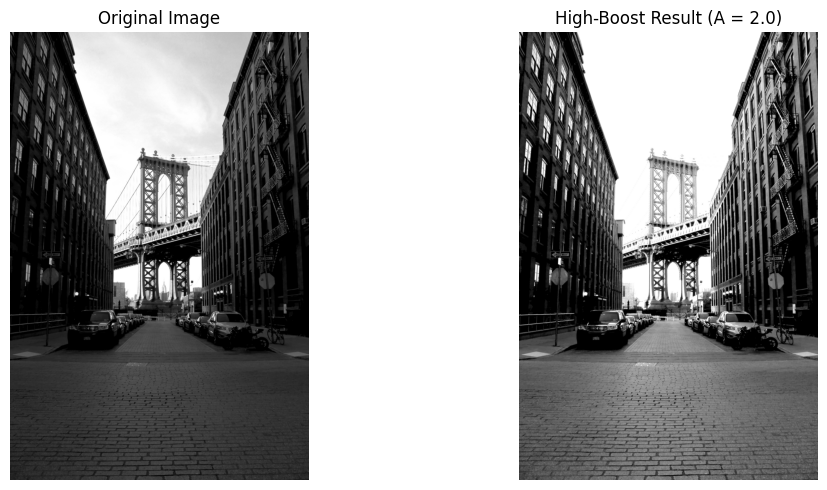

In [4]:
# High-boost filtering
A = 2.0

high_boost = (A - 1) * img + sharpened

# Keeping pixel values within valid range
high_boost = np.clip(high_boost, 0, 255)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_boost, cmap='gray')
plt.title(f"High-Boost Result (A = {A})")
plt.axis("off")

plt.tight_layout()
plt.show()

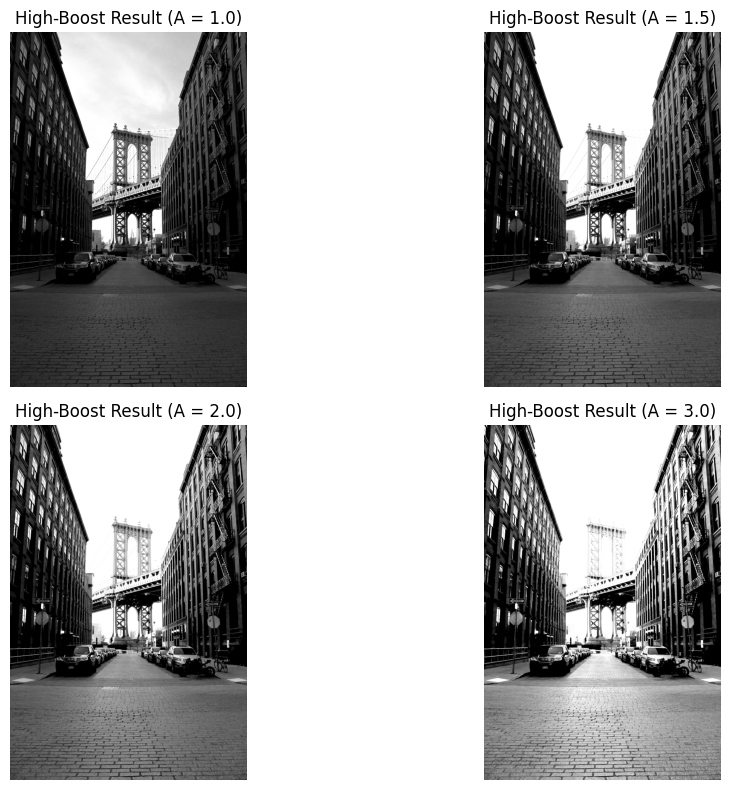

In [5]:
A_values = [1.0, 1.5, 2.0, 3.0]

plt.figure(figsize=(12, 8))

for i, A in enumerate(A_values):

    result = (A - 1) * img + sharpened

    result = np.clip(result, 0, 255)

    plt.subplot(2, 2, i + 1)
    plt.imshow(result, cmap='gray')
    plt.title(f"High-Boost Result (A = {A})")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Result
The high-boost filtering technique enhances the high-frequency components of the image while retaining the original image information. As the value of (A) increases, the contribution of the original image increases, producing stronger enhancement and sharper details. Very high values of (A) may cause excessive sharpening or intensity saturation.

#**2) Adaptive Local Enhancement**
Write a script that applies **Gamma correction locally**, using different $\gamma$ values for **dark and bright sub-regions** of an image.

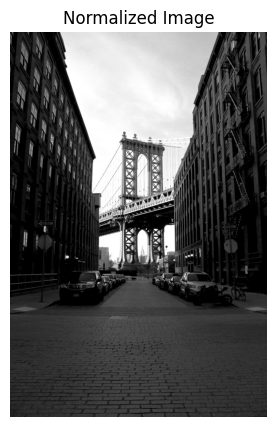

In [6]:
# Normalize image to [0, 1]
normalized = img / 255.0

plt.figure(figsize=(6, 5))
plt.imshow(normalized, cmap='gray')
plt.title("Normalized Image")
plt.axis("off")
plt.show()

A lower gamma value is applied to dark local regions to enhance their brightness, while a higher gamma value is applied to bright local regions to reduce excessive brightness.

In [7]:
gamma_dark = 0.5
gamma_bright = 1.5

Divide image into blocks, apply different gamma based on local brightness

In [8]:
# Local block size
block_size = 32

h, w = normalized.shape

# Output image
result = np.zeros_like(normalized)

for y in range(0, h, block_size):
    for x in range(0, w, block_size):

        # Extracting local block
        block = normalized[y:y+block_size, x:x+block_size]

        # Calculating local mean intensity
        local_mean = np.mean(block)

        # Selecting gamma based on local brightness
        if local_mean < 0.5:
            gamma = gamma_dark
        else:
            gamma = gamma_bright

        # Gamma correction
        result[y:y+block.shape[0],
               x:x+block.shape[1]] = block ** gamma

# Conversion to 8-bit
result_uint8 = np.uint8(result * 255)

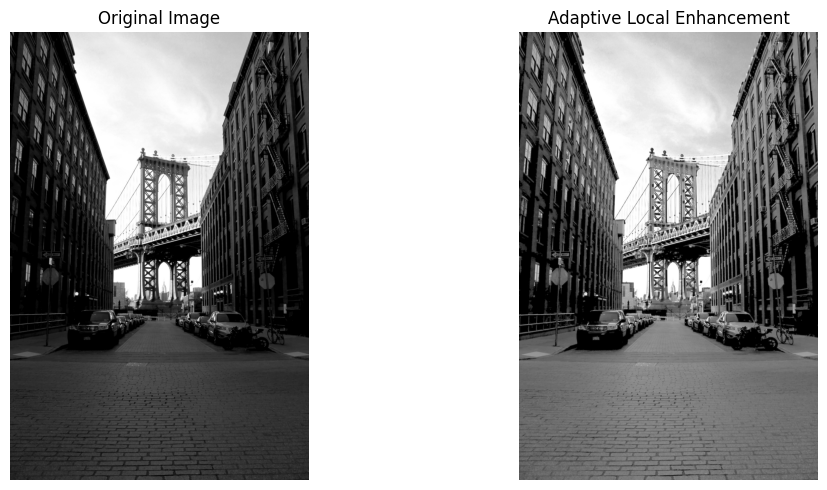

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_uint8, cmap='gray')
plt.title("Adaptive Local Enhancement")
plt.axis("off")

plt.tight_layout()
plt.show()

### Result

The image is divided into local blocks and the mean intensity of each block is calculated. Dark blocks are processed using gamma=0.5, while bright blocks are processed using gamma=1.5. Thus, gamma correction is adapted to the local brightness of different regions rather than applying a single gamma value to the entire image.